# **This is notebook based on: https://github.com/GuFeng-95/Denoising-Autoencoder/**

In [ ]:
import scipy.io as io
import numpy as np
import zipfile, io, os, sys
import pandas as pd

import requests, sys
import urllib.parse
from urllib.parse import urlencode

from google.colab import drive

import torch
from torch import nn
from torch.nn import init

from PIL import Image
from torch.utils.data import Dataset
import numpy as np
from skimage import data,img_as_float
from skimage.util import random_noise

import random
import torch.optim as optim
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt

from scipy.interpolate import griddata

In [ ]:
from google.colab import files as filescolab

In [ ]:
!pip install wandb -qU

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.1/266.1 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 4.8 MB/s eta 0:00:00


In [ ]:
import wandb
wandb.login()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
def loadTextFromYandexDisk(url: str, isZip = False):
  base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
  final_url = base_url + urlencode(dict(public_key=url))
  response = requests.get(final_url)
  download_url = response.json()['href']
  download_response = requests.get(download_url)

  if isZip:
    zip = zipfile.ZipFile(io.BytesIO(download_response.content))
    dirs = getZipDirs(zip, True)
    zip.extractall("/content/")
  else:
    download_response.encoding = download_response.apparent_encoding
    return download_response.text

In [ ]:
def getZipDirs(zip_f, isRootDirOnly = False, addPath = True):
  dirs = []
  for f in zip_f.namelist():
    zinfo = zip_f.getinfo(f)
    if zinfo.is_dir():
      if isRootDirOnly:     # Only root directories:
        # This is will work in any OS because the zip format specifies a forward slash.
        r_dir = f.split('/')
        r_dir = r_dir[0]
        if r_dir not in dirs:
          dirs.append(r_dir)
      else: # All directories:
          dirs.append(f)
  if addPath:
    for dir in dirs:
      sys.path.append(os.path.abspath('/content/' + dir + "/"))
  return dirs

In [ ]:
def read_data(path, r, z):
    df = pd.read_csv(path, names = ['r', 'z', 'f'], sep='\s+')

    try:
        df.iloc[0, :].str.isalpha().sum()
        df = pd.read_csv(path)
        df.columns = ['r', 'z', 'f']
    except AttributeError:
        pass

    if df.z.isnull().any():
        df = pd.read_csv(path, names = ['r', 'z', 'f'])
    if df.z.max() > 10:
        df.z *= 1e-2
        df.r *= 1e-2
    print(f'zmin_exp={df.z.min()}, zmax_exp={df.z.max()}')
    print(f'rmin_exp={df.r.min()}, rmax_exp={df.r.max()}')
    f = griddata((df.r, df.z), df['f'], (r, z))
    nani = np.argwhere(np.isnan(f))
    for i in nani:
        if i[0]-1 > 0 and ~np.isnan(f[i[0]-1, i[1]]):
            f[i[0], i[1]] = f[i[0]-1, i[1]]
        else:
            mask = np.isnan(f)
            f[mask] = np.mean(f[~mask])
    if 'T.txt' in path or '_temperature.csv' in path:
        if np.min(f) > 294:
            f -= (273.15 + 22)
        elif np.min(f) > 273:
            f -= 273.15
        else:
            f -= np.min(f)

    return f

# Loading experimantal data (displacement fields)

In [ ]:
# dataset with shape [379, 176]
#N, M = 379, 176

#ref='https://disk.yandex.ru/d/be_x3LmG5AbXFQ'
#loadTextFromYandexDisk(ref, isZip=True)

In [ ]:
# dataset with shape [448, 384]

ref='https://disk.yandex.ru/d/hmAQ2LiMuTFDSg'
loadTextFromYandexDisk(ref, isZip=True)

In [ ]:
displ = torch.load('/content/displ_tensors_448x384/IMG_2490.pt')

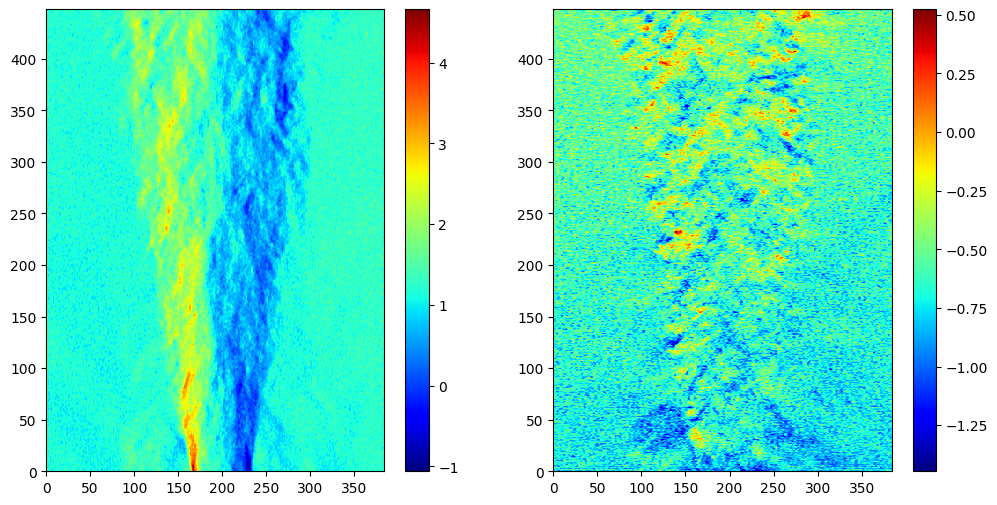

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

im=ax[0].pcolor(displ[0], cmap='jet')
plt.colorbar(im, ax=ax[0])

im=ax[1].pcolor(displ[1], cmap='jet')
plt.colorbar(im, ax=ax[1])
plt.show()

# Denoising autoencoder model (DAE)

In [ ]:
class Reshape(nn.Module):
    def __init__(self, *args):
        super(Reshape, self).__init__()
        self.shape = args

    def forward(self, x):
        return x.view((x.size(0),)+self.shape)


class SEAttention(nn.Module):

    def __init__(self, channel=512,reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )


    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                init.constant_(m.weight, 1)
                init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                init.normal_(m.weight, std=0.001)
                if m.bias is not None:
                    init.constant_(m.bias, 0)

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class autoencoder_n(nn.Module):
    def __init__(self,w,h,vector_l):
        super(autoencoder_n, self).__init__()

        self.vector_l=vector_l

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=1, padding=1),  # (b, 16, 384, 192)
            nn.Tanh(),
            nn.MaxPool2d(2, stride=2),  # (b, 16, 192, 96)
            nn.Conv2d(16, 8, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2, stride=2),  # (b, 8, 96, 48)
            nn.Conv2d(8, 8, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2, stride=2),  # (b, 8, 48, 24)
            nn.Conv2d(8, 8, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2, stride=2),  # (b, 8, 24, 12)
            nn.Conv2d(8, 4, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2, stride=2),  # (b, 4, 12, 6)
            nn.Conv2d(4, 4, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2, stride=2),  # (b, 4, 6, 3)
            Reshape(int(4*w*h/4096)),
            nn.Linear(int(4*w*h/4096),self.vector_l)
        )

        self.decoder = nn.Sequential(
            nn.Linear(self.vector_l,int(4*w*h/4096)),
            Reshape(4,int(w/64),int(h/64)),
            nn.Upsample(scale_factor=2, mode='nearest'),# (b, 4, 12, 6)
            nn.Conv2d(4, 4, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.Upsample(scale_factor=2, mode='nearest'),  # (b, 4, 24, 12)
            nn.Conv2d(4, 8, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.Upsample(scale_factor=2, mode='nearest'),  # (b, 8, 48, 24)
            nn.Conv2d(8, 8, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.Upsample(scale_factor=2, mode='nearest'),  # (b, 8, 96, 48)
            nn.Conv2d(8, 8, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.Upsample(scale_factor=2, mode='nearest'),  # (b, 8, 192, 96)
            nn.Conv2d(8, 16, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.Upsample(scale_factor=2, mode='nearest'),  # (b, 16, 384, 192)
            nn.Conv2d(16, 1, 3, stride=1, padding=1)
        )

    def forward(self, x):
        encode = self.encoder(x)
        decode = self.decoder(encode)
        return encode, decode

class autoencoder_attention_n(nn.Module):
    def __init__(self,w,h,n):
        super(autoencoder_attention_n, self).__init__()
        self.n=n

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=1, padding=1),  # (b, 16, 384, 192)
            nn.Tanh(),
            nn.MaxPool2d(2, stride=2),  # (b, 16, 192, 96)
            SEAttention(16, 2),
            nn.Conv2d(16, 8, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2, stride=2),  # (b, 8, 96, 48)
            nn.Conv2d(8, 8, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2, stride=2),  # (b, 8, 48, 24)
            nn.Conv2d(8, 8, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2, stride=2),  # (b, 8, 24, 12)
            nn.Conv2d(8, 4, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2, stride=2),  # (b, 4, 12, 6)
            nn.Conv2d(4, 4, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2, stride=2),  # (b, 4, 12, 6)
            # SEAttention(16,2),
            # nn.AdaptiveAvgPool2d(1)
            Reshape(int(4 * w * h / 4096)),
            nn.Linear(int(4 * w * h / 4096), self.n)

        )

        self.decoder = nn.Sequential(
            nn.Linear(self.n, int(4 * w * h / 4096)),
            Reshape(4, int(w / 64), int(h / 64)),
            nn.Upsample(scale_factor=2, mode='nearest'),  # (b, 1, 12, 6)
            nn.Conv2d(4, 4, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.Upsample(scale_factor=2, mode='nearest'),# (b, 1, 12, 6)
            nn.Conv2d(4, 8, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.Upsample(scale_factor=2, mode='nearest'),  # (b, 8, 48, 24)
            nn.Conv2d(8, 8, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.Upsample(scale_factor=2, mode='nearest'),  # (b, 8, 96, 48)
            nn.Conv2d(8, 8, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.Upsample(scale_factor=2, mode='nearest'),  # (b, 8, 192, 96)
            nn.Conv2d(8, 16, 3, stride=1, padding=1),
            nn.Tanh(),
            nn.Upsample(scale_factor=2, mode='nearest'),  # (b, 16, 384, 192)
            SEAttention(16, 2),
            nn.Conv2d(16, 1, 3, stride=1, padding=1)
        )

    def forward(self, x):
        encode = self.encoder(x)
        decode = self.decoder(encode)
        return encode, decode


In [ ]:
import glob
from tqdm import tqdm

class displDataset(Dataset):
    def __init__(
        self,
        transform=None,
        data=None,
        N = 448,
        M = 384,
        path='/content/data_tensors/content/data_tensors/tensors',
        num=-1
    ):
        self.transform = transform
        self.loaded_images = torch.zeros(0, 2,  N, M)
        self.num=num
        path += '/*.pt'

        files = glob.glob(path)
        if self.num == -1:
            self.num = len(files)
        for filename in tqdm(files[:self.num]):
            z = torch.load(filename)
            z = z[:, :N, :M]
            self.loaded_images = torch.cat((self.loaded_images,z.unsqueeze(0)))

        #self.loaded_targets = torch.clone(self.loaded_images).detach()


    def normalize(self, data_n):
        #u, v, T, p,
        data_n /= 5
        return data_n


    def __getitem__(self, i):

        img = self.loaded_images[i]
        #target = self.loaded_targets[i]

        #img += torch.randn(img.shape) * 0.05 * torch.max(img)

        #img = self.normalize(img)
        #target = self.normalize(target)

        return img

    def __len__(self):
        return len(self.loaded_images)

In [ ]:
bs = 32
N = 448
M = 384

trainset = displDataset(N=N, M=M, path='/content/displ_tensors_448x384')
train_loader = DataLoader(trainset, batch_size=bs, shuffle=True, num_workers=2)

len(train_loader)

100%|██████████| 399/399 [01:23<00:00,  4.75it/s]


13

Test

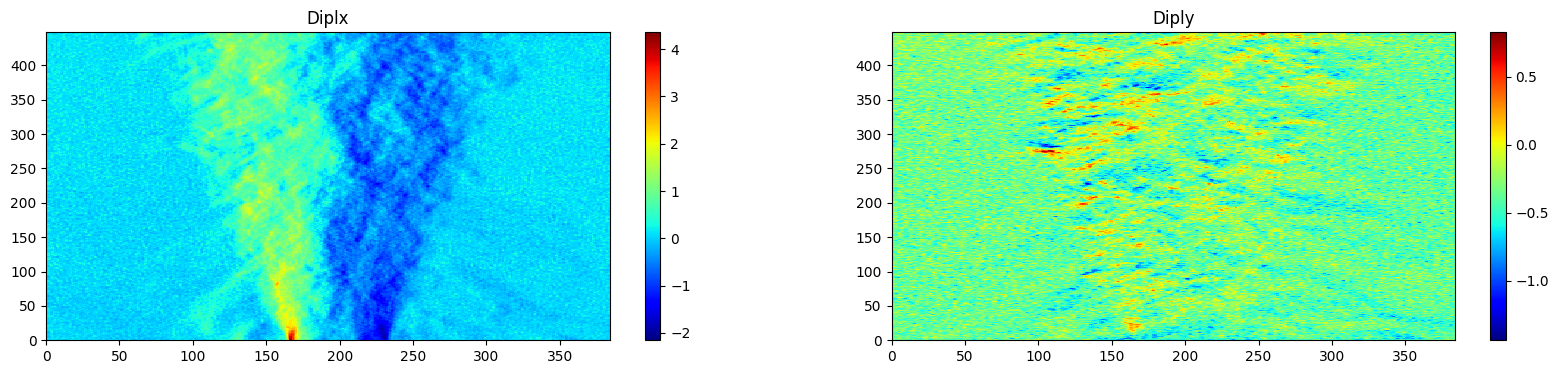

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(20, 4))

for i, (im) in enumerate(train_loader):

    im1 = axs[0].pcolor(im[0][0].numpy(), cmap='jet')
    axs[0].set_title('Diplx')

    plt.colorbar(im1)

    im1 = axs[1].pcolor(im[0][1].numpy(), cmap='jet')
    axs[1].set_title('Diply')
    plt.colorbar(im1)

    if i ==0:
        break

plt.show()

In [ ]:
wandb.init(
        settings=wandb.Settings(start_method="thread"),
        project="DAE_gung2024",
        config={
            "lr": 1e-3,
            "comment": 'DISPLx_v=16'
            })

loss_data,▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▇▇▃▂▂▆▂▃▃▂▂
loss_data,0.13273


In [ ]:
!pip install -q lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.5/841.5 kB 40.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.6/801.6 kB 44.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 36.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 64.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 54.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━

In [ ]:
import lightning as L

# DISPL_X

In [ ]:
from torch.nn import MSELoss

class Lit(L.LightningModule):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.metric = nn.L1Loss()

    def configure_optimizers(self):
        optimizer = optim.Adam(model.parameters(), lr=0.001,weight_decay=0)
        return optimizer

    def training_step(self, batch, batch_idx):
        train_inputs = batch[:, 0,:,:].unsqueeze(1)

        vector, train_outputs = model(train_inputs)
        loss = self.metric(train_outputs, train_inputs)

        metrics = {'loss_data': loss}
        wandb.log(metrics)

        return loss

    def validation_step(self, batch, batch_idx):
        pass


    def on_train_epoch_end(self):
        pass


    def on_validation_epoch_end(self):
        pass

In [ ]:
vector_number = 16
model = autoencoder_n(N, M, vector_number)
model = model.to(device)

# Loading weights


In [ ]:
PATH = '/content/my_model_displ_x_AE_not_self_at_v=16_epoch=130.pth'
model.load_state_dict(torch.load(PATH))
model.eval()

In [ ]:
disply_all = trainset.loaded_images[:,0,:,:].unsqueeze(1).to('cpu')
model.to('cpu')
disply_all_model_out = model(disply_all)

# Training

In [ ]:
num_epochs = 130
L.seed_everything(42)
#torch.autograd.set_detect_anomaly(True)
lit_model_DAE = Lit(model)

trainer_u = L.Trainer(max_epochs=num_epochs)

trainer_u.fit(model=lit_model_DAE, train_dataloaders=train_loader)

#wandb.finish()

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name   | Type          | Params
-----------------------------------------
0 | model  | autoencoder_n | 11.4 K
1 | metric | L1Loss        | 0     
-----------------------------------------
11.4 K    Trainable params
0         Non-trainable params
11.4 K    Total params
0.046     Total 

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=130` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=130` reached.


In [ ]:
torch.save(model.state_dict(), 'my_model_displ_x_AE_not_self_at_v=16.pth')

# Displ_Y

In [ ]:
from torch.nn import MSELoss

class Lit(L.LightningModule):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.metric = nn.L1Loss()

    def configure_optimizers(self):
        optimizer = optim.Adam(model.parameters(), lr=0.001,weight_decay=0)
        return optimizer

    def training_step(self, batch, batch_idx):
        train_inputs = batch[:, 1,:,:].unsqueeze(1)

        vector, train_outputs = model(train_inputs)
        loss = self.metric(train_outputs, train_inputs)

        metrics = {'loss_data': loss}
        wandb.log(metrics)

        return loss

    def validation_step(self, batch, batch_idx):
        pass


    def on_train_epoch_end(self):
        pass


    def on_validation_epoch_end(self):
        pass

In [ ]:
vector_number = 16
model = autoencoder_n(N, M, vector_number)
model = model.to(device)

In [ ]:
num_epochs = 110
L.seed_everything(42)
#torch.autograd.set_detect_anomaly(True)
lit_model_DAE = Lit(model)

trainer_u = L.Trainer(max_epochs=num_epochs)

trainer_u.fit(model=lit_model_DAE, train_dataloaders=train_loader)

#wandb.finish()

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/trainer/configuration_validator.py:74: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name   | Type          | Params
-----------------------------------------
0 | model  | autoencoder_n | 11.4

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=110` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=110` reached.


In [ ]:
torch.save(model.state_dict(), 'my_model_displ_y_AE_not_self_at_v=16.pth')

# Test

torch.Size([32, 1, 448, 384])


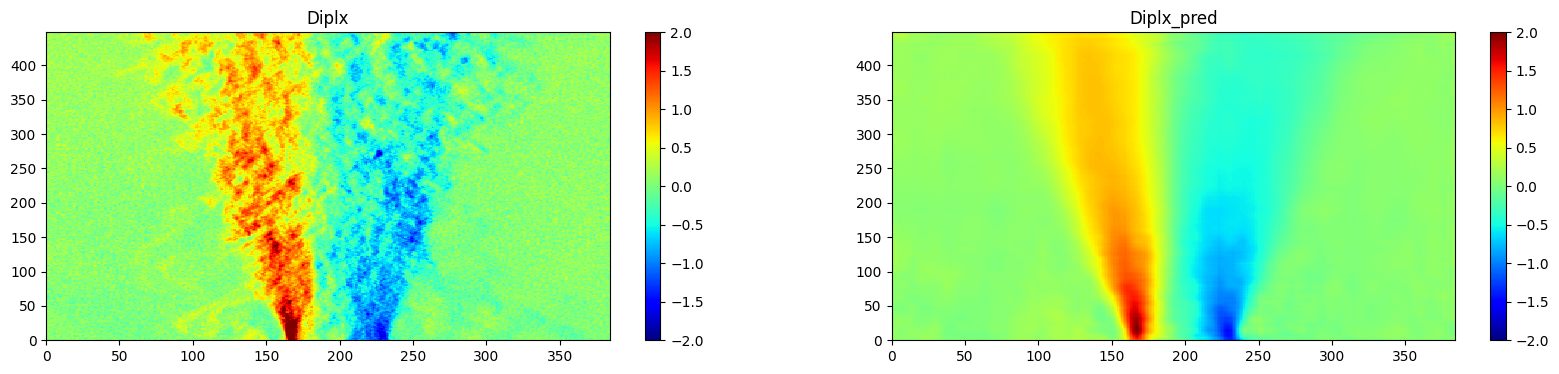

In [ ]:
# not SA_epoch=130_v=16
fig, axs = plt.subplots(1,2, figsize=(20, 4))

vmin, vmax = -2, 2
for i, (im) in enumerate(train_loader):
    idx = 10

    im1 = axs[0].pcolor(im[idx][0].detach().cpu().numpy(), cmap='jet', vmin=vmin , vmax=vmax)
    axs[0].set_title('Diplx')

    plt.colorbar(im1)

    _, out = model(im[:, 0, :, :].unsqueeze(1))
    print(out.shape)

    im1 = axs[1].pcolor(out[idx][0].detach().cpu().numpy(), cmap='jet', vmin=vmin , vmax=vmax)
    axs[1].set_title('Diplx_pred')
    plt.colorbar(im1)

    if i ==0:
        break

plt.show()

torch.Size([32, 1, 448, 384])


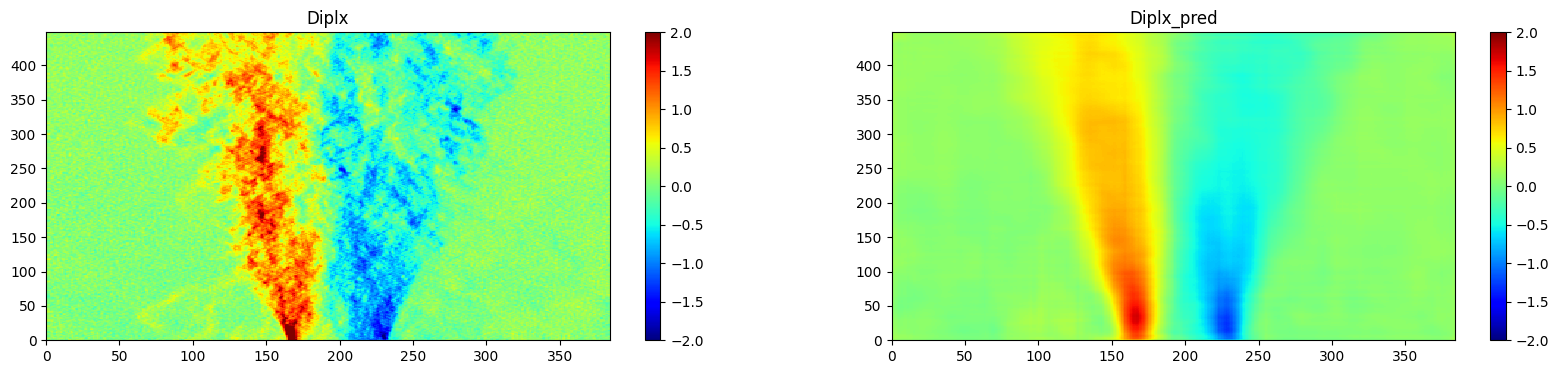

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(20, 4))

vmin, vmax = -2, 2
for i, (im) in enumerate(train_loader):
    idx = 4

    im1 = axs[0].pcolor(im[idx][0].detach().cpu().numpy(), cmap='jet', vmin=vmin , vmax=vmax)
    axs[0].set_title('Diplx')

    plt.colorbar(im1)

    _, out = model(im[:, 0, :, :].unsqueeze(1))
    print(out.shape)

    im1 = axs[1].pcolor(out[idx][0].detach().cpu().numpy(), cmap='jet', vmin=vmin , vmax=vmax)
    axs[1].set_title('Diplx_pred')
    plt.colorbar(im1)

    if i ==0:
        break

plt.show()

# Test displY

torch.Size([32, 1, 448, 384])


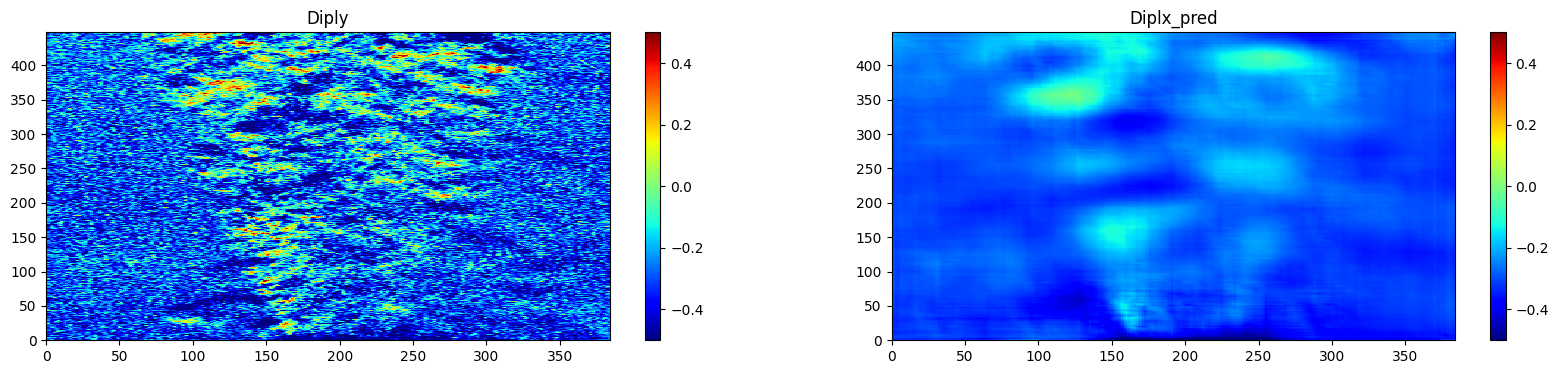

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(20, 4))

vmin, vmax = -0.5, 0.5
for i, (im) in enumerate(train_loader):
    idx = 30

    im1 = axs[0].pcolor(im[idx][1].detach().cpu().numpy(), cmap='jet', vmin=vmin , vmax=vmax)
    axs[0].set_title('Diply')

    plt.colorbar(im1)

    _, out = model(im[:, 1, :, :].unsqueeze(1))
    print(out.shape)

    im1 = axs[1].pcolor(out[idx][0].detach().cpu().numpy(), cmap='jet', vmin=vmin , vmax=vmax)
    axs[1].set_title('Diplx_pred')
    plt.colorbar(im1)

    if i ==0:
        break

plt.show()

torch.Size([32, 1, 448, 384])


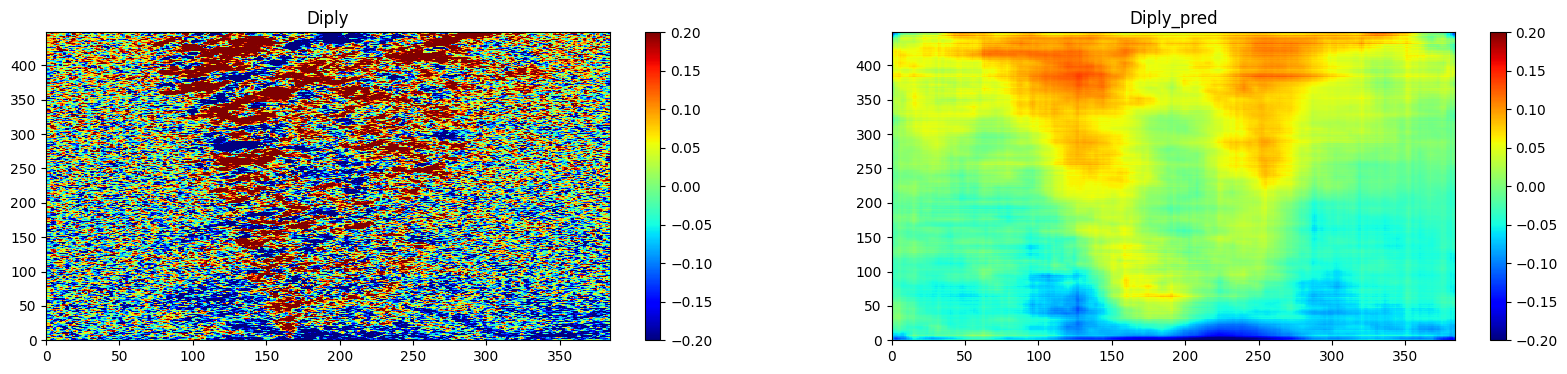

In [ ]:
# v = 8, not self-attention

fig, axs = plt.subplots(1,2, figsize=(20, 4))

vmin, vmax = -0.2, 0.2
for i, (im) in enumerate(train_loader):
    idx = 10

    im1 = axs[0].pcolor(im[idx][1].detach().cpu().numpy(), cmap='jet', vmin=vmin , vmax=vmax)
    axs[0].set_title('Diply')

    plt.colorbar(im1)

    _, out = model(im[:, 1, :, :].unsqueeze(1))
    print(out.shape)

    im1 = axs[1].pcolor(out[idx][0].detach().cpu().numpy(), cmap='jet', vmin=vmin , vmax=vmax)
    axs[1].set_title('Diply_pred')
    plt.colorbar(im1)

    if i ==0:
        break

plt.show()

torch.Size([32, 1, 448, 384])


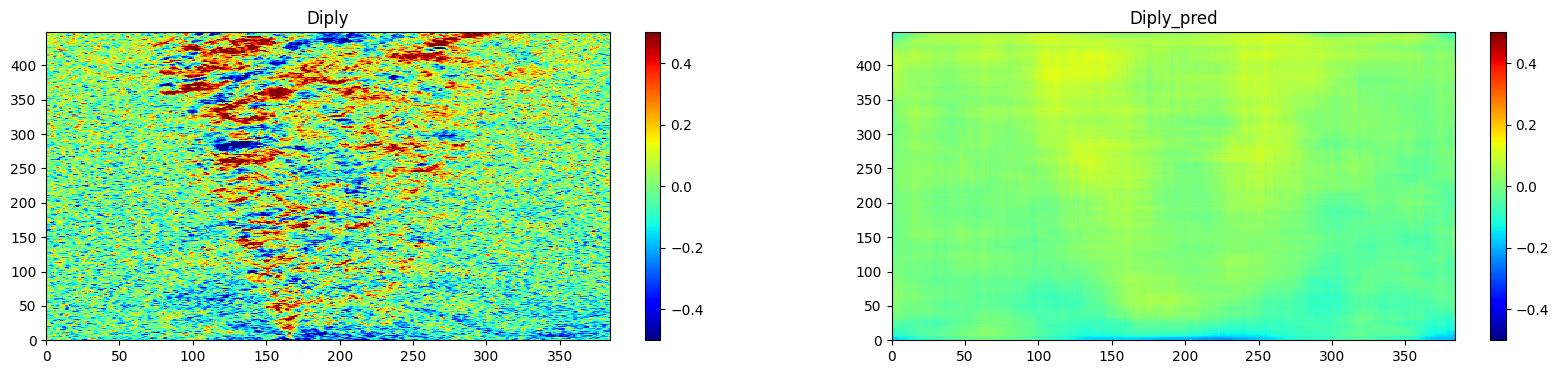

In [ ]:
# v = 8, not self-attention

fig, axs = plt.subplots(1,2, figsize=(20, 4))

vmin, vmax = -0.5, 0.5
for i, (im) in enumerate(train_loader):
    idx = 10

    im1 = axs[0].pcolor(im[idx][1].detach().cpu().numpy(), cmap='jet', vmin=vmin , vmax=vmax)
    axs[0].set_title('Diply')

    plt.colorbar(im1)

    _, out = model(im[:, 1, :, :].unsqueeze(1))
    print(out.shape)

    im1 = axs[1].pcolor(out[idx][0].detach().cpu().numpy(), cmap='jet', vmin=vmin , vmax=vmax)
    axs[1].set_title('Diply_pred')
    plt.colorbar(im1)

    if i ==0:
        break

plt.show()

torch.Size([32, 1, 448, 384])


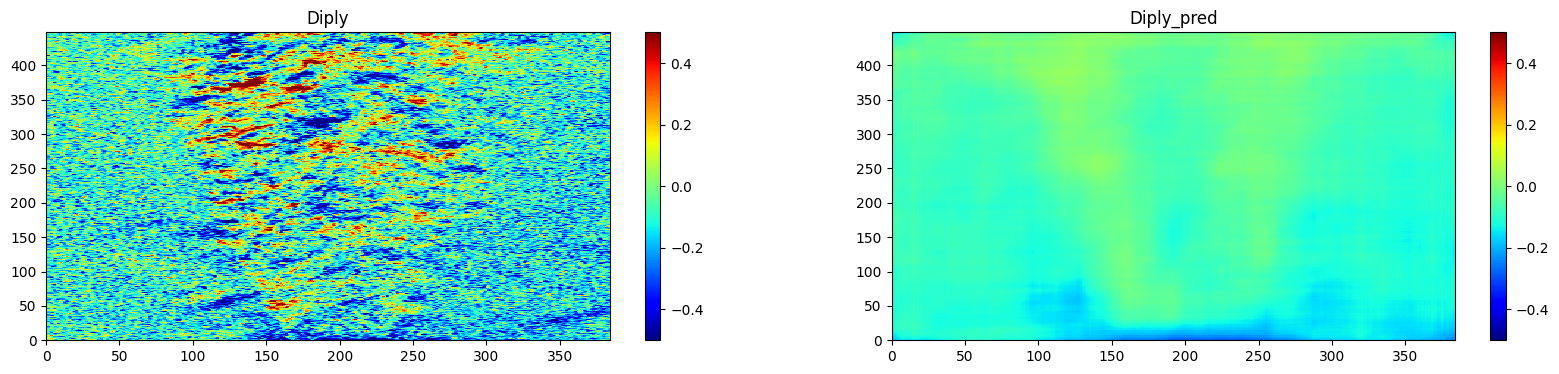

In [ ]:
# v = 16, not self-attention

fig, axs = plt.subplots(1,2, figsize=(20, 4))

vmin, vmax = -0.5, 0.5
for i, (im) in enumerate(train_loader):
    idx = 20

    im1 = axs[0].pcolor(im[idx][1].detach().cpu().numpy(), cmap='jet', vmin=vmin , vmax=vmax)
    axs[0].set_title('Diply')

    plt.colorbar(im1)

    _, out = model(im[:, 1, :, :].unsqueeze(1))
    print(out.shape)

    im1 = axs[1].pcolor(out[idx][0].detach().cpu().numpy(), cmap='jet', vmin=vmin , vmax=vmax)
    axs[1].set_title('Diply_pred')
    plt.colorbar(im1)

    if i ==0:
        break

plt.show()

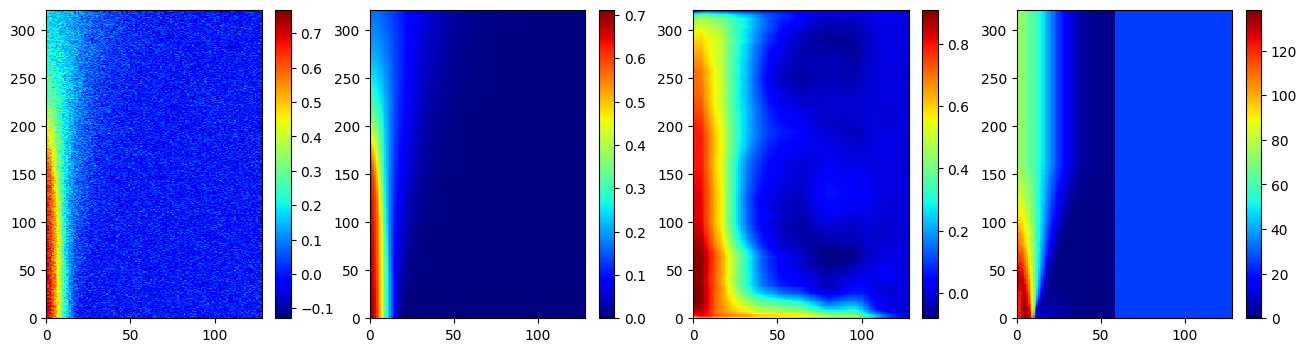

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

for i, (img, tar) in enumerate(train_loader):
  im=ax[0].pcolor(img[0,0].detach().cpu().numpy(), cmap='jet')
  plt.colorbar(im, ax=ax[0])

  im=ax[1].pcolor(tar[0,0].detach().cpu().numpy(), cmap='jet')
  plt.colorbar(im, ax=ax[1])

  _, out_model = model(torch.tensor(Texp).float().unsqueeze(0).unsqueeze(0).to(device))

  im=ax[2].pcolor(out_model[0,0].detach().cpu().numpy(), cmap='jet')
  plt.colorbar(im, ax=ax[2])

  im=ax[3].pcolor(Texp, cmap='jet')
  plt.colorbar(im, ax=ax[3])

  break

  plt.show()
